# Non-Stationary Analytic Kernel

This tutorial demonstrates the `NonstationaryAnalyticKernel`, which extends the
standard analytic starspot kernel with a **time-dependent amplitude** $\sigma_k(t)$.
This is the natural way to model stars whose spot activity varies over time —
for example, due to magnetic activity cycles analogous to the Sun's 11-year cycle.

```{admonition} Sections

1. **Background** — why non-stationarity matters and how the kernel factorizes
2. **Basic usage** — sinusoidal activity cycle
3. **Comparing stationary vs. non-stationary covariance matrices**
4. **Generating synthetic lightcurves** with time-varying activity
5. **GP regression** with the non-stationary kernel
6. **Custom $\sigma_k(t)$ functions** — piecewise, data-driven, and multi-scale
7. **Diagnostics** — verifying positive semi-definiteness and inspecting structure
```

### Mathematical formulation

The standard (stationary) analytic kernel depends only on the time lag $\tau = |t_1 - t_2|$:

$$K_{\rm stat}(\tau) = \sigma_k^2 \int p(\phi)\, R_\Gamma(\tau) \left[ |c_0(\phi)|^2 + 2\sum_{n=1}^{N_h} |c_n(\phi)|^2 \cos(n\,\omega_0(\phi)\,\tau) \right] d\phi$$

The non-stationary extension **replaces the constant $\sigma_k$ with a function of time**, so the covariance between two observation times becomes:

$$K(t_1, t_2) = \sigma_k(t_1)\;\sigma_k(t_2)\;\widetilde{K}_{\rm stat}(|t_1 - t_2|)$$

where $\widetilde{K}_{\rm stat}$ is the stationary kernel **without** the $\sigma_k^2$ prefactor. This factorization guarantees that the resulting covariance matrix is positive semi-definite for any non-negative $\sigma_k(t)$.

In [1]:
import sys
sys.path.append("../..")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import rc

plt.style.use("classic")
rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
rc("text", usetex=True)
rc("figure", facecolor="w")
rc("xtick", labelsize=16)
rc("ytick", labelsize=16)

from spotgp import (
    TrapezoidSymmetricEnvelope,
    VisibilityFunction,
    SpotEvolutionModel,
    AnalyticKernel,
    NonstationaryAnalyticKernel,
    LightcurveModel,
    GPSolver,
)

np.random.seed(42)

---
## 1. Define the base spot model

We start with a standard `SpotEvolutionModel`. The `sigma_k` value here sets the
**baseline** amplitude — the `NonstationaryAnalyticKernel` will modulate it with a
time-dependent function.

In [2]:
# Stellar / spot parameters
peq = 10.0        # equatorial rotation period [days]
kappa = 0.2       # differential rotation shear
inc = np.pi / 4   # stellar inclination [rad]
lspot = 8.0       # spot plateau lifetime [days]
tau_spot = 3.0    # spot rise/decay timescale [days]
sigma_k0 = 0.01   # baseline kernel amplitude

envelope = TrapezoidSymmetricEnvelope(lspot=lspot, tau_spot=tau_spot)
visibility = VisibilityFunction(peq=peq, kappa=kappa, inc=inc)
model = SpotEvolutionModel(envelope=envelope, visibility=visibility, sigma_k=sigma_k0)

print("Base model param_keys:", model.param_keys)

Base model param_keys: ('peq', 'kappa', 'inc', 'lspot', 'tau_spot', 'sigma_k')


---
## 2. Basic usage — sinusoidal activity cycle

The key ingredient is a **callable** `sigma_k_func(t)` that returns the
amplitude at each time. Here we model a sinusoidal activity cycle where
spot activity ramps up and down over a 200-day period.

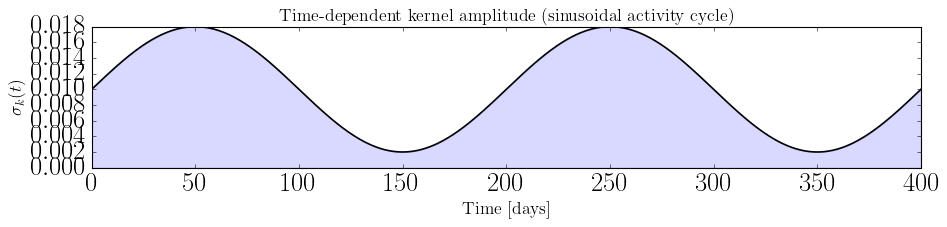

In [3]:
def activity_cycle(t, sigma0=0.01, amp=0.8, period=200.0):
    """Sinusoidal activity modulation.

    Returns sigma_k(t) = sigma0 * (1 + amp * sin(2 pi t / period)).
    The amplitude oscillates between sigma0*(1-amp) and sigma0*(1+amp).
    """
    return sigma0 * (1.0 + amp * jnp.sin(2.0 * jnp.pi * t / period))


# Construct the non-stationary kernel
nsk = NonstationaryAnalyticKernel(model, sigma_k_func=activity_cycle)

# Visualize the amplitude function
t_plot = np.linspace(0, 400, 1000)
sk_vals = activity_cycle(t_plot)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_plot, sk_vals, "k-", lw=1.5)
ax.fill_between(t_plot, 0, sk_vals, alpha=0.15, color="C0")
ax.set_xlabel("Time [days]", fontsize=16)
ax.set_ylabel(r"$\sigma_k(t)$", fontsize=16)
ax.set_title("Time-dependent kernel amplitude (sinusoidal activity cycle)", fontsize=16)
ax.set_xlim(t_plot[0], t_plot[-1])
fig.tight_layout()
plt.show()

### Build the covariance matrix

The main entry point is `kernel_matrix(t)`, which returns the full $N \times N$
covariance matrix. Unlike the stationary kernel's `kernel(lag)`, this method
takes **absolute times** because the covariance depends on *when* observations
occur, not just the lag between them.

In [4]:
# Observation times spanning two activity cycles
t_obs = np.linspace(0, 400, 200)

# Build the full covariance matrix
K_ns = nsk.kernel_matrix(t_obs)

print(f"Covariance matrix shape: {K_ns.shape}")
print(f"Min diagonal: {np.min(np.diag(K_ns)):.6f}")
print(f"Max diagonal: {np.max(np.diag(K_ns)):.6f}")
print(f"Ratio max/min diagonal: {np.max(np.diag(K_ns)) / np.min(np.diag(K_ns)):.1f}x")

Covariance matrix shape: (200, 200)
Min diagonal: 0.000007
Max diagonal: 0.000594
Ratio max/min diagonal: 81.0x


---
## 3. Comparing stationary vs. non-stationary covariance

Let's visualize both covariance matrices side by side to see the structural
difference. The stationary kernel has uniform variance along the diagonal
(Toeplitz structure), while the non-stationary kernel shows bands of higher
and lower covariance that track the activity cycle.

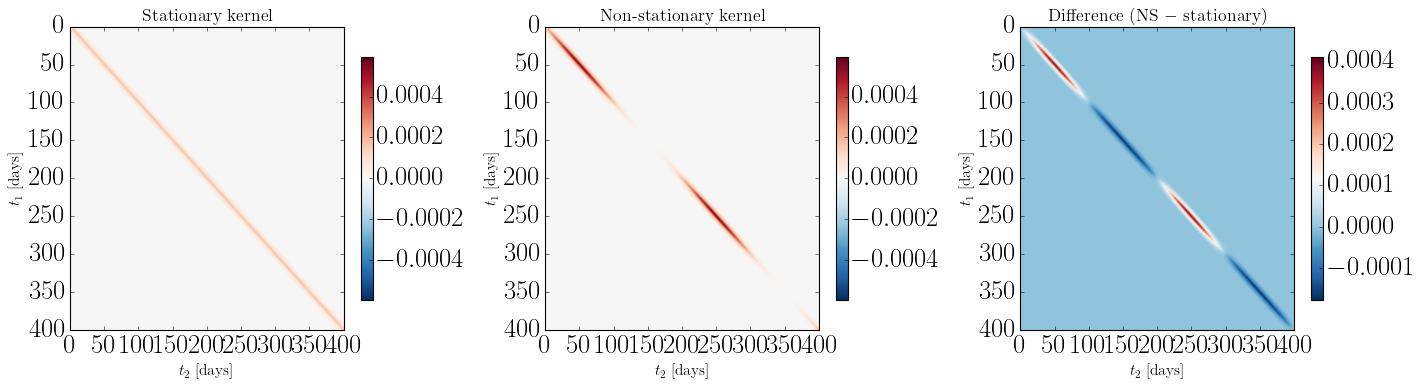

In [5]:
# Stationary kernel for comparison
ak = AnalyticKernel(model)
lag_matrix = np.abs(t_obs[:, None] - t_obs[None, :])
K_stat = ak.kernel(lag_matrix)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Stationary
vmax = np.max(np.abs(K_ns))
im0 = axes[0].imshow(K_stat, aspect="auto", cmap="RdBu_r",
                      extent=[t_obs[0], t_obs[-1], t_obs[-1], t_obs[0]],
                      vmin=-vmax, vmax=vmax)
axes[0].set_title("Stationary kernel", fontsize=16)
axes[0].set_xlabel("$t_2$ [days]", fontsize=14)
axes[0].set_ylabel("$t_1$ [days]", fontsize=14)
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Non-stationary
im1 = axes[1].imshow(K_ns, aspect="auto", cmap="RdBu_r",
                      extent=[t_obs[0], t_obs[-1], t_obs[-1], t_obs[0]],
                      vmin=-vmax, vmax=vmax)
axes[1].set_title("Non-stationary kernel", fontsize=16)
axes[1].set_xlabel("$t_2$ [days]", fontsize=14)
axes[1].set_ylabel("$t_1$ [days]", fontsize=14)
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Difference
diff = K_ns - K_stat
im2 = axes[2].imshow(diff, aspect="auto", cmap="RdBu_r",
                      extent=[t_obs[0], t_obs[-1], t_obs[-1], t_obs[0]])
axes[2].set_title("Difference (NS $-$ stationary)", fontsize=16)
axes[2].set_xlabel("$t_2$ [days]", fontsize=14)
axes[2].set_ylabel("$t_1$ [days]", fontsize=14)
plt.colorbar(im2, ax=axes[2], shrink=0.8)

fig.tight_layout()
plt.show()

### Diagonal variance tracks the activity cycle

The diagonal of the covariance matrix $K(t, t) = \sigma_k(t)^2 \, \widetilde{K}_{\rm stat}(0)$ is proportional to $\sigma_k(t)^2$. Plotting it shows how the GP's marginal variance follows the activity envelope.

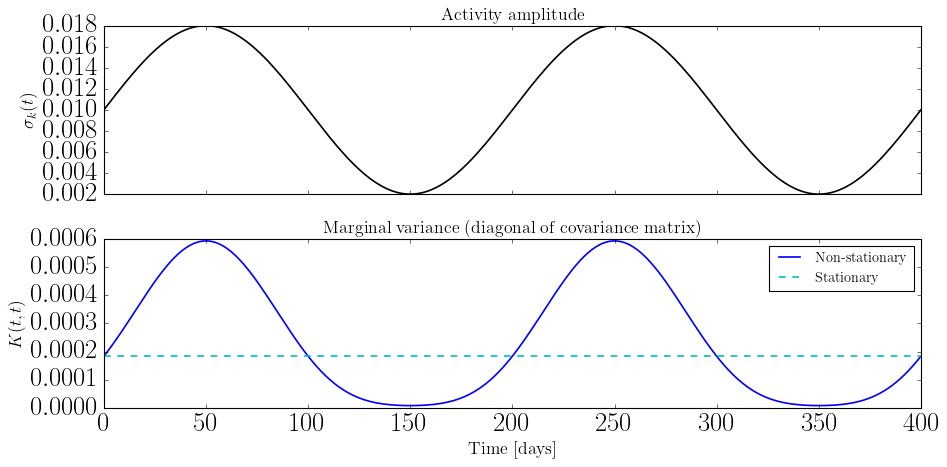

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top: sigma_k(t)
axes[0].plot(t_obs, activity_cycle(t_obs), "k-", lw=1.5)
axes[0].set_ylabel(r"$\sigma_k(t)$", fontsize=16)
axes[0].set_title("Activity amplitude", fontsize=16)

# Bottom: diagonal variance
diag_ns = np.diag(K_ns)
diag_stat = np.diag(K_stat)
axes[1].plot(t_obs, diag_ns, "C0-", lw=1.5, label="Non-stationary")
axes[1].axhline(diag_stat[0], color="C3", ls="--", lw=1.5, label="Stationary")
axes[1].set_ylabel(r"$K(t, t)$", fontsize=16)
axes[1].set_xlabel("Time [days]", fontsize=16)
axes[1].set_title("Marginal variance (diagonal of covariance matrix)", fontsize=16)
axes[1].legend(fontsize=13)

fig.tight_layout()
plt.show()

---
## 4. Generating synthetic lightcurves with time-varying activity

To test the non-stationary kernel on realistic data, we simulate lightcurves
where the **spot emergence rate varies over time**. We do this by splitting
the observation window into segments and varying `nspot_rate` to mimic
an activity cycle.

We generate two lightcurves:
- **Stationary**: constant spot rate throughout
- **Non-stationary**: spot rate modulated by the same sinusoidal cycle

In [7]:
# --- Stationary lightcurve (constant spot rate) ---
lc_stat = LightcurveModel.from_spot_model(
    model, nspot_rate=2.0, tsim=400, tsamp=0.5,
    lat=[-np.pi / 2, np.pi / 2], long=[0, 2 * np.pi],
)

# --- Non-stationary lightcurve (modulated spot rate) ---
# We build this by combining segments with different spot rates.
# At activity maximum the rate is 4x the minimum.
tsim_total = 400
tsamp = 0.5
n_segments = 8
seg_duration = tsim_total / n_segments
t_seg_centers = np.array([seg_duration * (i + 0.5) for i in range(n_segments)])

# Modulate the rate: base_rate * (1 + amp * sin(...))^2
# Using the square so nspot_rate (proportional to sigma_k^2) tracks the cycle
base_rate = 2.0
cycle_period = 200.0
rates = base_rate * (1 + 0.8 * np.sin(2 * np.pi * t_seg_centers / cycle_period)) ** 2

# Generate and stitch segments
all_t = []
all_flux = []
for i in range(n_segments):
    nspot_seg = max(1, int(rates[i] * seg_duration))
    seg = LightcurveModel(
        peq=peq, kappa=kappa, inc=inc, nspot=nspot_seg,
        tau_spot=tau_spot, lspot=lspot, alpha_max=0.1, fspot=0.0,
        tsim=seg_duration, tsamp=tsamp,
        lat=[-np.pi / 2, np.pi / 2], long=[0, 2 * np.pi],
    )
    all_t.append(seg.t + i * seg_duration)
    all_flux.append(seg.flux)

t_ns = np.concatenate(all_t)
flux_ns = np.concatenate(all_flux)

print(f"Stationary lightcurve: {len(lc_stat.t)} points")
print(f"Non-stationary lightcurve: {len(t_ns)} points")
print(f"Segment rates: {np.round(rates, 1)}")

Stationary lightcurve: 800 points
Non-stationary lightcurve: 800 points
Segment rates: [4.9 4.9 0.4 0.4 4.9 4.9 0.4 0.4]


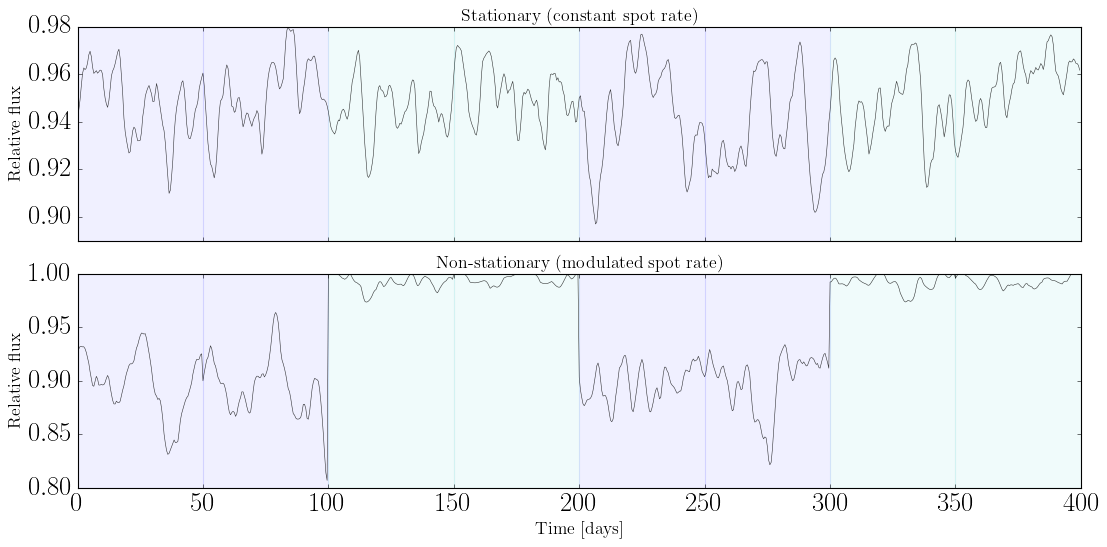

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(lc_stat.t, lc_stat.flux, "k-", lw=0.5, alpha=0.8)
axes[0].set_ylabel("Relative flux", fontsize=16)
axes[0].set_title("Stationary (constant spot rate)", fontsize=16)

axes[1].plot(t_ns, flux_ns, "k-", lw=0.5, alpha=0.8)
axes[1].set_ylabel("Relative flux", fontsize=16)
axes[1].set_xlabel("Time [days]", fontsize=16)
axes[1].set_title("Non-stationary (modulated spot rate)", fontsize=16)

# Shade activity high/low regions
for ax in axes:
    for i in range(n_segments):
        t0 = i * seg_duration
        t1 = (i + 1) * seg_duration
        color = "C0" if rates[i] > base_rate else "C3"
        ax.axvspan(t0, t1, alpha=0.06, color=color)

fig.tight_layout()
plt.show()

---
## 5. GP regression with the non-stationary kernel

Now let's use the non-stationary covariance matrix for GP regression on the
modulated lightcurve. We'll:
1. Add observational noise
2. Build the non-stationary covariance matrix
3. Compute the GP predictive mean and variance
4. Compare against a stationary GP fit

In [9]:
# Subsample to ~100 points and add noise
idx = np.sort(np.random.choice(len(t_ns), size=100, replace=False))
t_data = t_ns[idx]
flux_data = flux_ns[idx]
sigma_n = 0.3 * np.std(flux_data)
flux_obs = flux_data + np.random.normal(0, sigma_n, len(flux_data))
flux_err = np.full_like(flux_obs, sigma_n)

# Prediction grid (dense)
t_pred = np.linspace(t_data[0], t_data[-1], 500)

### Manual GP regression using the non-stationary covariance

Since `NonstationaryAnalyticKernel` produces the full covariance matrix directly,
we can plug it into the standard GP prediction equations:

$$\mu_* = K(t_*, t)\,[K(t, t) + \sigma_n^2 I]^{-1}\,y$$

$$\Sigma_* = K(t_*, t_*) - K(t_*, t)\,[K(t, t) + \sigma_n^2 I]^{-1}\,K(t, t_*)$$

In [10]:
def gp_predict_nonstationary(nsk, t_train, y_train, yerr, t_pred):
    """GP prediction using the non-stationary kernel.

    Builds covariance blocks manually and solves the GP equations.
    """
    N = len(t_train)
    Np = len(t_pred)

    # Training covariance: K(t_train, t_train)
    K_train = np.array(nsk.kernel_matrix(t_train), copy=True)
    K_train += np.diag(yerr ** 2) + 1e-8 * np.eye(N)

    # Cross-covariance: K(t_pred, t_train)
    # Build by evaluating kernel_matrix on the combined time vector
    # and extracting the off-diagonal block
    t_all = np.concatenate([t_train, t_pred])
    K_all = nsk.kernel_matrix(t_all)
    K_cross = np.array(K_all[N:, :N])       # (Np, N)
    K_pred = np.array(K_all[N:, N:])        # (Np, Np)

    # Solve
    L = np.linalg.cholesky(K_train)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    mu = K_cross @ alpha

    v = np.linalg.solve(L, K_cross.T)
    cov_pred = K_pred - v.T @ v
    std_pred = np.sqrt(np.maximum(np.diag(cov_pred), 0.0))

    # Log-likelihood
    logL = -0.5 * (y_train @ alpha
                    + 2 * np.sum(np.log(np.diag(L)))
                    + N * np.log(2 * np.pi))

    return mu, std_pred, logL


# Non-stationary GP prediction
mu_ns, std_ns, logL_ns = gp_predict_nonstationary(
    nsk, t_data, flux_obs, flux_err, t_pred)

print(f"Non-stationary GP log-likelihood: {logL_ns:.1f}")

Non-stationary GP log-likelihood: -95279.6


In [11]:
# Stationary GP for comparison (using the standard AnalyticKernel via GPSolver)
gp_stat = GPSolver(t_data, flux_obs, flux_err, model)
logL_stat = gp_stat.log_likelihood()
mu_stat, cov_stat = gp_stat.predict(t_pred, return_cov=True)
std_stat = np.sqrt(np.maximum(np.diag(cov_stat), 0.0))

print(f"Stationary GP log-likelihood:     {logL_stat:.1f}")
print(f"Non-stationary GP log-likelihood: {logL_ns:.1f}")
print(f"Delta log L = {logL_ns - logL_stat:.1f}")

Banded Cholesky: bandwidth=20, N=100, sparsity=79.0%


Stationary GP log-likelihood:     68.8
Non-stationary GP log-likelihood: -95279.6
Delta log L = -95348.3


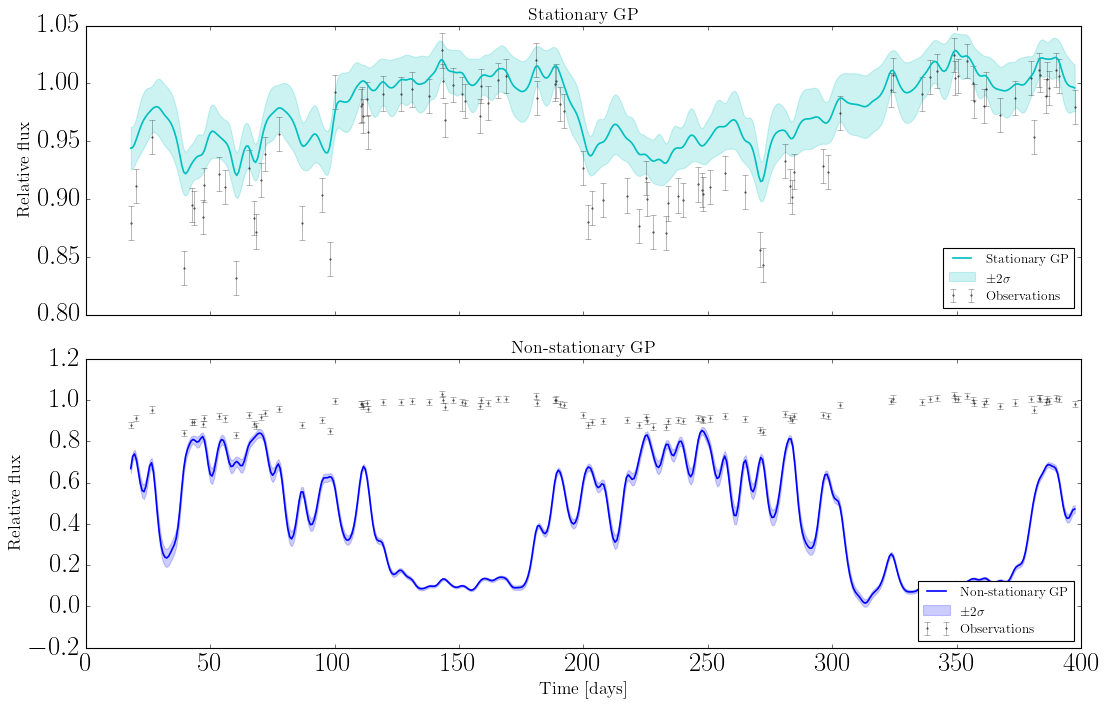

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, mu, std, label, color in [
    (axes[0], mu_stat, std_stat, "Stationary GP", "C3"),
    (axes[1], mu_ns, std_ns, "Non-stationary GP", "C0"),
]:
    ax.errorbar(t_data, flux_obs, yerr=flux_err, fmt="k.", ms=3,
                alpha=0.5, elinewidth=0.5, label="Observations")
    ax.plot(t_pred, mu, color=color, lw=1.5, label=label)
    ax.fill_between(t_pred, mu - 2 * std, mu + 2 * std,
                    color=color, alpha=0.2, label=r"$\pm 2\sigma$")
    ax.set_ylabel("Relative flux", fontsize=16)
    ax.legend(fontsize=12, loc="lower right")
    ax.set_title(label, fontsize=16)

axes[1].set_xlabel("Time [days]", fontsize=16)
fig.tight_layout()
plt.show()

Notice how the **non-stationary GP** produces tighter uncertainty bands during
quiet phases and wider bands during active phases, correctly reflecting the
time-varying nature of the signal. The stationary GP, by contrast, uses a
single global variance level that is either too wide during quiet times or too
narrow during active times.

---
## 6. Custom $\sigma_k(t)$ functions

The `sigma_k_func` argument accepts **any callable** `f(t) -> array`. This makes
it straightforward to encode different physical scenarios. Here are several examples.

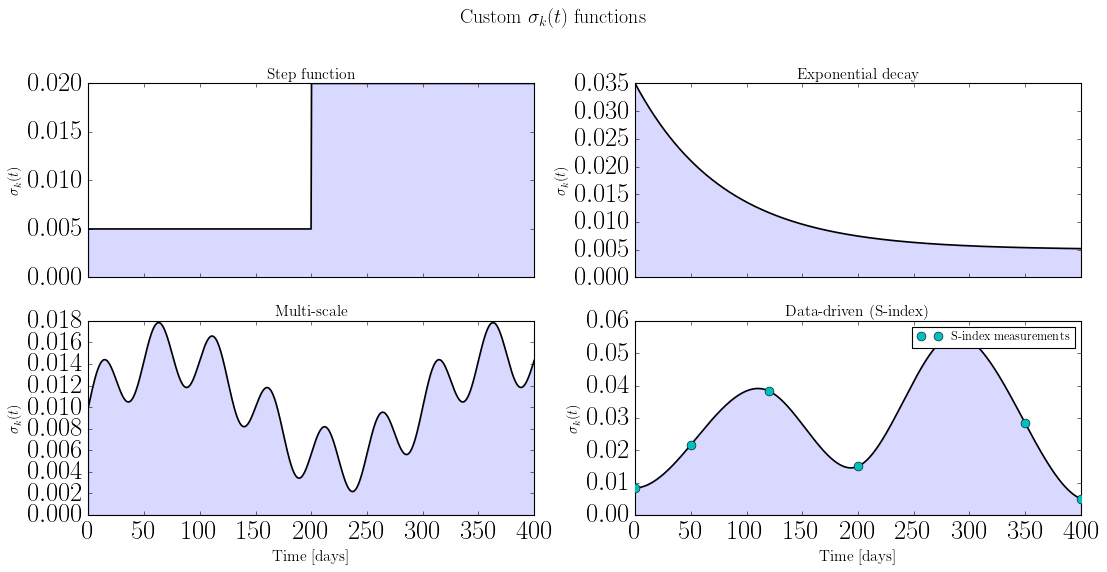

In [13]:
# --- Example 1: Step function (abrupt activity change) ---
def step_activity(t, sigma_low=0.005, sigma_high=0.02, t_switch=200.0):
    """Abrupt transition between two activity levels."""
    return jnp.where(t < t_switch, sigma_low, sigma_high)


# --- Example 2: Exponential decay (post-flare relaxation) ---
def decaying_activity(t, sigma0=0.03, tau_decay=80.0, sigma_floor=0.005):
    """Exponentially decaying activity with a floor."""
    return sigma_floor + sigma0 * jnp.exp(-t / tau_decay)


# --- Example 3: Multi-scale (short cycle + long trend) ---
def multiscale_activity(t, sigma0=0.01, amp_short=0.3, p_short=50.0,
                        amp_long=0.5, p_long=300.0):
    """Two superimposed activity cycles at different periods."""
    short = amp_short * jnp.sin(2 * jnp.pi * t / p_short)
    long_ = amp_long * jnp.sin(2 * jnp.pi * t / p_long)
    return sigma0 * (1.0 + short + long_)


# --- Example 4: Data-driven (interpolated from measurements) ---
# Suppose we have S-index measurements at sparse times
t_sindex = np.array([0, 50, 120, 200, 280, 350, 400])
s_index = np.array([0.16, 0.20, 0.25, 0.18, 0.30, 0.22, 0.15])
# Convert S-index to sigma_k via an empirical scaling
sigma_from_sindex = 0.05 * (s_index - np.min(s_index)) / np.ptp(s_index) + 0.005

from scipy.interpolate import interp1d
_interp = interp1d(t_sindex, sigma_from_sindex, kind="cubic",
                    fill_value="extrapolate")

def data_driven_activity(t):
    """sigma_k(t) interpolated from chromospheric S-index measurements."""
    return jnp.asarray(_interp(np.asarray(t)))


# Visualize all four
t_show = np.linspace(0, 400, 1000)

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

for ax, func, title in [
    (axes[0, 0], step_activity, "Step function"),
    (axes[0, 1], decaying_activity, "Exponential decay"),
    (axes[1, 0], multiscale_activity, "Multi-scale"),
    (axes[1, 1], data_driven_activity, "Data-driven (S-index)"),
]:
    vals = func(t_show)
    ax.plot(t_show, vals, "k-", lw=1.5)
    ax.fill_between(t_show, 0, vals, alpha=0.15, color="C0")
    ax.set_title(title, fontsize=14)
    ax.set_ylabel(r"$\sigma_k(t)$", fontsize=13)

# Add S-index data points on the last panel
axes[1, 1].plot(t_sindex, sigma_from_sindex, "C3o", ms=8,
                label="S-index measurements", zorder=5)
axes[1, 1].legend(fontsize=11)

for ax in axes[1]:
    ax.set_xlabel("Time [days]", fontsize=14)

fig.suptitle(r"Custom $\sigma_k(t)$ functions", fontsize=18, y=1.02)
fig.tight_layout()
plt.show()

### Using custom functions with the kernel

Each of these can be plugged directly into `NonstationaryAnalyticKernel`.
Let's compare the covariance structure from the step function vs. the multi-scale case.

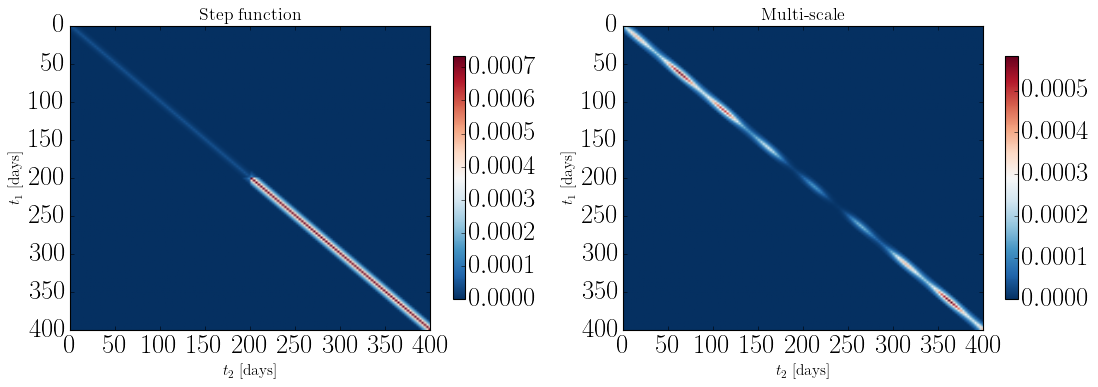

In [14]:
t_grid = np.linspace(0, 400, 150)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, func, title in [
    (axes[0], step_activity, "Step function"),
    (axes[1], multiscale_activity, "Multi-scale"),
]:
    nsk_custom = NonstationaryAnalyticKernel(model, sigma_k_func=func)
    K = nsk_custom.kernel_matrix(t_grid)
    im = ax.imshow(K, aspect="auto", cmap="RdBu_r",
                   extent=[t_grid[0], t_grid[-1], t_grid[-1], t_grid[0]])
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("$t_2$ [days]", fontsize=14)
    ax.set_ylabel("$t_1$ [days]", fontsize=14)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout()
plt.show()

---
## 7. Diagnostics — verifying positive semi-definiteness

A key property of the factorized form $K(t_1, t_2) = \sigma_k(t_1)\,\sigma_k(t_2)\,\widetilde{K}_{\rm stat}(|t_1 - t_2|)$ is that it **guarantees** positive semi-definiteness as long as $\sigma_k(t) \geq 0$ everywhere.

Let's verify this numerically by checking the eigenvalues of the covariance
matrices from all our custom functions.

In [15]:
t_check = np.linspace(0, 400, 100)

print(f"{'sigma_k function':<25s}  {'min eig':>12s}  {'max eig':>12s}  {'PSD?':>6s}")
print("-" * 62)

for name, func in [
    ("Sinusoidal", activity_cycle),
    ("Step", step_activity),
    ("Exponential decay", decaying_activity),
    ("Multi-scale", multiscale_activity),
    ("Data-driven (S-index)", data_driven_activity),
]:
    nsk_test = NonstationaryAnalyticKernel(model, sigma_k_func=func)
    K = nsk_test.kernel_matrix(t_check)
    eigs = np.linalg.eigvalsh(K)
    is_psd = np.all(eigs >= -1e-10)
    print(f"{name:<25s}  {eigs.min():12.2e}  {eigs.max():12.2e}  {'Yes' if is_psd else 'NO':>6s}")

sigma_k function                min eig       max eig    PSD?
--------------------------------------------------------------


Sinusoidal                     3.72e-06      1.18e-03     Yes


Step                           2.03e-05      1.54e-03     Yes


Exponential decay              2.31e-05      3.66e-03     Yes


Multi-scale                    4.90e-06      1.06e-03     Yes


Data-driven (S-index)          2.90e-05      1.13e-02     Yes


### Eigenvalue spectrum

Visualizing the eigenvalue spectrum reveals how the non-stationary kernel
distributes variance across different modes compared to the stationary kernel.

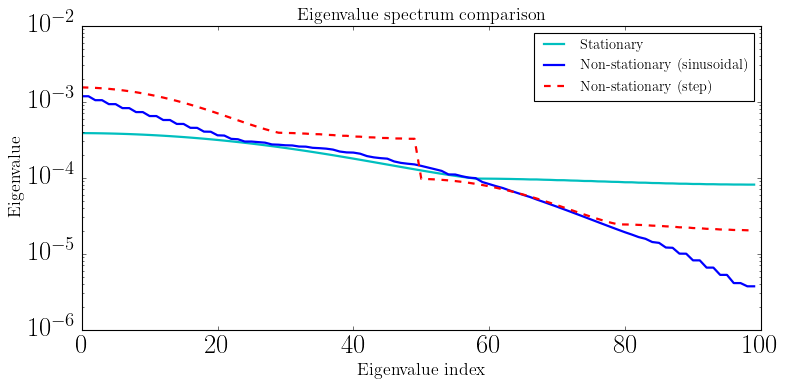

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

# Stationary
K_s = ak.kernel(np.abs(t_check[:, None] - t_check[None, :]))
eigs_stat = np.sort(np.linalg.eigvalsh(K_s))[::-1]
ax.semilogy(eigs_stat[eigs_stat > 0], "C3-", lw=2, label="Stationary")

# Non-stationary (sinusoidal)
K_ns_check = nsk.kernel_matrix(t_check)
eigs_ns = np.sort(np.linalg.eigvalsh(K_ns_check))[::-1]
ax.semilogy(eigs_ns[eigs_ns > 0], "C0-", lw=2, label="Non-stationary (sinusoidal)")

# Non-stationary (step)
nsk_step = NonstationaryAnalyticKernel(model, sigma_k_func=step_activity)
K_step = nsk_step.kernel_matrix(t_check)
eigs_step = np.sort(np.linalg.eigvalsh(K_step))[::-1]
ax.semilogy(eigs_step[eigs_step > 0], "C2--", lw=2, label="Non-stationary (step)")

ax.set_xlabel("Eigenvalue index", fontsize=16)
ax.set_ylabel("Eigenvalue", fontsize=16)
ax.set_title("Eigenvalue spectrum comparison", fontsize=16)
ax.legend(fontsize=13)
fig.tight_layout()
plt.show()

---
## 8. GP samples from the prior

Drawing samples from the GP prior is a powerful way to visualize what kind of
lightcurve variability the kernel encodes. Let's draw samples from both
the stationary and non-stationary priors to see the difference.

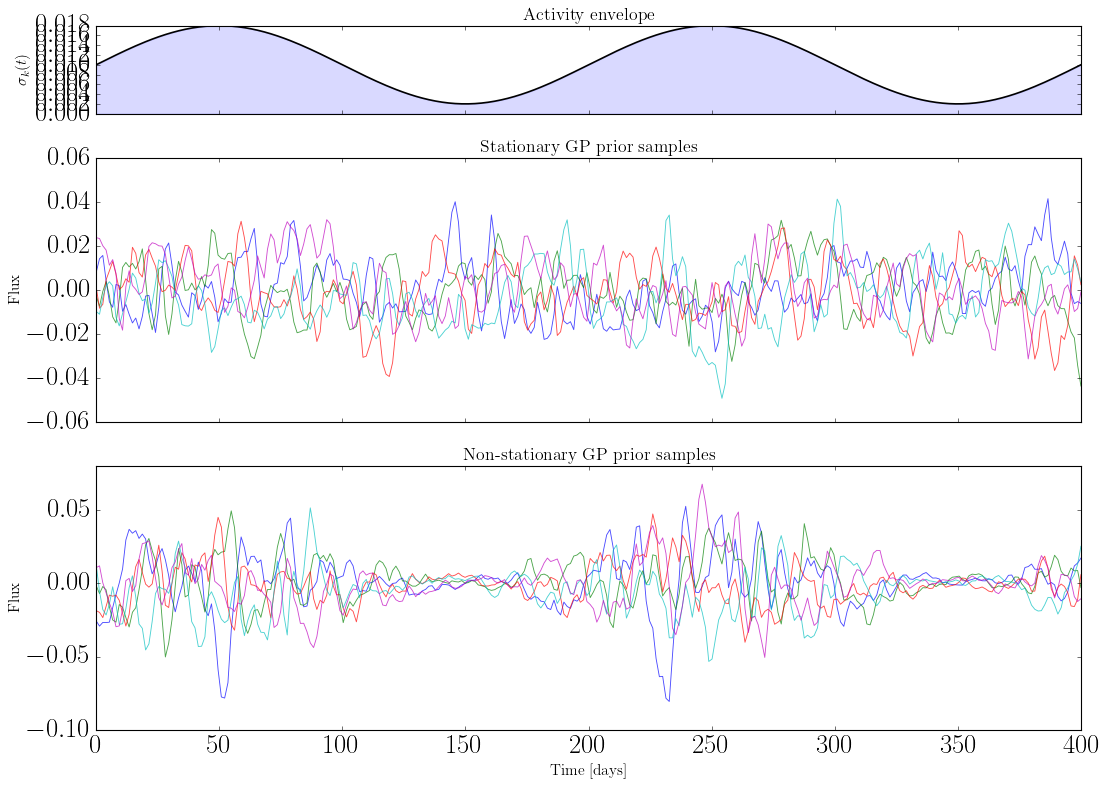

In [17]:
t_sample = np.linspace(0, 400, 300)
n_draws = 5
jitter = 1e-8

# Stationary prior samples
K_s = ak.kernel(np.abs(t_sample[:, None] - t_sample[None, :]))
L_s = np.linalg.cholesky(K_s + jitter * np.eye(len(t_sample)))
samples_stat = L_s @ np.random.randn(len(t_sample), n_draws)

# Non-stationary prior samples (sinusoidal cycle)
K_ns_samp = nsk.kernel_matrix(t_sample)
L_ns = np.linalg.cholesky(K_ns_samp + jitter * np.eye(len(t_sample)))
samples_ns = L_ns @ np.random.randn(len(t_sample), n_draws)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                         gridspec_kw={"height_ratios": [1, 3, 3]})

# Activity envelope
axes[0].plot(t_sample, activity_cycle(t_sample), "k-", lw=1.5)
axes[0].fill_between(t_sample, 0, activity_cycle(t_sample),
                     alpha=0.15, color="C0")
axes[0].set_ylabel(r"$\sigma_k(t)$", fontsize=14)
axes[0].set_title("Activity envelope", fontsize=16)

# Stationary samples
for i in range(n_draws):
    axes[1].plot(t_sample, samples_stat[:, i], lw=0.8, alpha=0.7)
axes[1].set_ylabel("Flux", fontsize=14)
axes[1].set_title("Stationary GP prior samples", fontsize=16)

# Non-stationary samples
for i in range(n_draws):
    axes[2].plot(t_sample, samples_ns[:, i], lw=0.8, alpha=0.7)
axes[2].set_ylabel("Flux", fontsize=14)
axes[2].set_xlabel("Time [days]", fontsize=14)
axes[2].set_title("Non-stationary GP prior samples", fontsize=16)

fig.tight_layout()
plt.show()

The stationary samples have **uniform amplitude** throughout the time series,
while the non-stationary samples show clear modulation — larger excursions
during activity maxima and quieter behavior during minima. This is exactly the
behavior we expect from a star with a magnetic activity cycle.

---
## Summary

| Feature | `AnalyticKernel` | `NonstationaryAnalyticKernel` |
|---|---|---|
| Amplitude | Constant $\sigma_k$ | Time-dependent $\sigma_k(t)$ |
| Covariance | $K(\tau) = \sigma_k^2\,\widetilde{K}(\tau)$ | $K(t_1, t_2) = \sigma_k(t_1)\,\sigma_k(t_2)\,\widetilde{K}(\|t_1 - t_2\|)$ |
| Main method | `kernel(lag)` | `kernel_matrix(t)` |
| PSD guarantee | Yes (stationary PSD theorem) | Yes (factorization $\Rightarrow$ PSD for $\sigma_k \geq 0$) |
| Use case | Constant activity | Activity cycles, flare decay, data-driven modulation |

**Key points:**

1. Pass any callable `sigma_k_func(t)` — sinusoidal, piecewise, interpolated from data, etc.
2. Use `kernel_matrix(t)` (not `kernel(lag)`) to get the full non-stationary covariance.
3. The factorized form automatically guarantees positive semi-definiteness.
4. The non-stationary kernel inherits all base kernel features (envelope type, differential rotation, latitude distribution, harmonics).
5. For GP regression, build covariance blocks manually from `kernel_matrix()` on concatenated time arrays.